In [462]:
# !pip install kagglehub

In [463]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("shivamb/netflix-shows")

# print("Path to dataset files:", path)

In [464]:
# Load csv data info dataframe 
import numpy as np 
import pandas as pd
from scipy import stats

df = pd.read_csv(r"C:\Users\Rajan Shrestha\.cache\kagglehub\datasets\shivamb\netflix-shows\versions\5\netflix_titles.csv")

In [465]:
df.sample()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
249,s250,Movie,The Loud House Movie,Dave Needham,"Asher Bishop, David Tennant, Michelle Gomez, J...",NaN,"August 20, 2021",2021,TV-Y7,88 min,"Children & Family Movies, Comedies, Music & Mu...","With his parents and all 10 sisters in tow, Li..."


In [466]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [467]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

### 1. Clean and convert data types 

In [468]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(),format='%B %d, %Y')

# Extract numeric value and unit from duration
df[['duration_value', 'duration_unit']] = df['duration'].str.extract(r'(\d+)\s*(\w+)')
df['duration_unit'] = df['duration_unit'].str.lower()

#Normalize unit names ('season'->'seasons')
df['duration_unit'] = df['duration_unit'].replace({'season':'seasons'})

### 2. Input missing values

In [469]:
## 2.1 Categorical colums: fill with 'Unknown' or Mode
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [470]:
df.isna().sum()

show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added        10
release_year       0
rating             0
duration           3
listed_in          0
description        0
duration_value     3
duration_unit      3
dtype: int64

In [471]:
# Fill missing date_added using release_year (as YYYY-01-01)
df['date_added'] = df['date_added'].fillna(
    pd.to_datetime(df['release_year'].astype(str) + '-01-01')
)

In [472]:
df.isna().sum()

show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added        0
release_year      0
rating            0
duration          3
listed_in         0
description       0
duration_value    3
duration_unit     3
dtype: int64

In [473]:
## 2.2 Impute missing duration using type=based medians
df['duration_value'] = pd.to_numeric(df['duration_value'])
movie_median_dur = df[df['type'] == 'Movie']['duration_value'].median()
tv_median_dur = df[df['type'] == 'TV Show']['duration_value'].median()

In [474]:
df.loc[df['duration_value'].isna() & (df['type'] == 'Movie'), 'duration_value'] = movie_median_dur
df.loc[df['duration_value'].isna() & (df['type'] == 'TV Show'), 'duration_value'] = tv_median_dur
df['duration_unit'] = df['duration_unit'].fillna(df['type'].map({'Movie':'min', 'TV Show':'seasons'}))

### 3. Process comma-separated list features into python list 

In [475]:
df['genres'] = df['listed_in'].str.split(', ')
df['country_list'] = df['country'].str.split(', ')
df['cast_list'] = df['cast'].str.split(', ')

### 4. Feature engineering

In [476]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()
df['num_cast_members'] = df['cast_list'].apply(lambda x: 0 if x == ['Unknown'] else len(x))

In [477]:
# Drop duplicates based on title and type
df = df.drop_duplicates(subset=['title', 'type']).reset_index(drop=True)

---
## Visualization/plot

In [478]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

### 1. Distribution of Movies vs. TV Shows

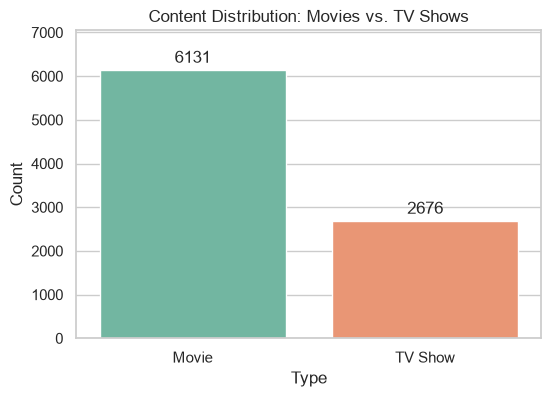

In [479]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x='type', hue='type', palette='Set2', legend=False)

# Loop over all containers to annotate every bar
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Content Distribution: Movies vs. TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')

# Add extra headroom at the top for labels
plt.ylim(0, df['type'].value_counts().max() * 1.15)

plt.show()

### 2. Top 10 Genres (genres)

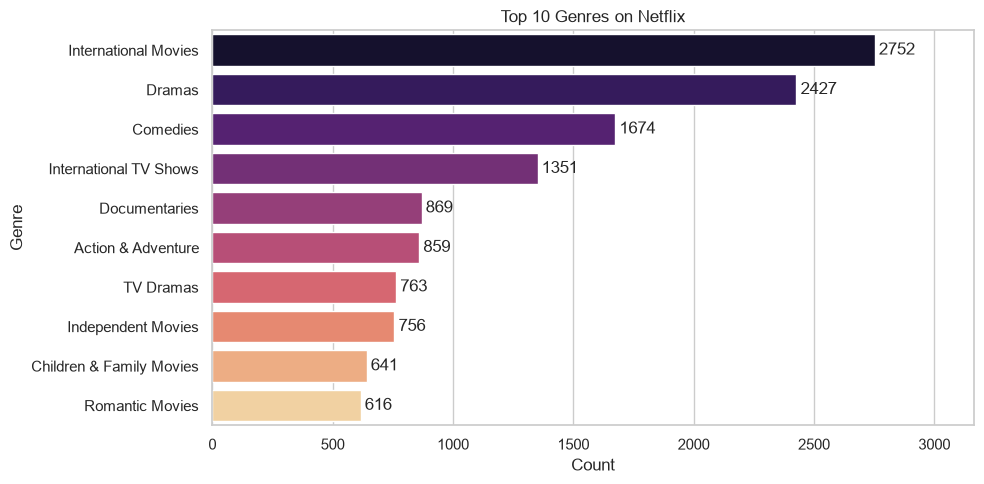

In [480]:
# Prepare data
exploded_genres = df.explode('genres').reset_index(drop=True)
top_10 = exploded_genres['genres'].value_counts().head(10).reset_index()
top_10.columns = ['Genre', 'Count']

# Plot without legend
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=top_10,
    x='Count',
    y='Genre',
    hue='Genre',
    palette='magma',
    legend=False
)

# Add data labels on bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.xlim(0, top_10['Count'].max() * 1.15)
plt.tight_layout()
plt.show()

### 3. Movie Duration Distribution (`duration_value`)

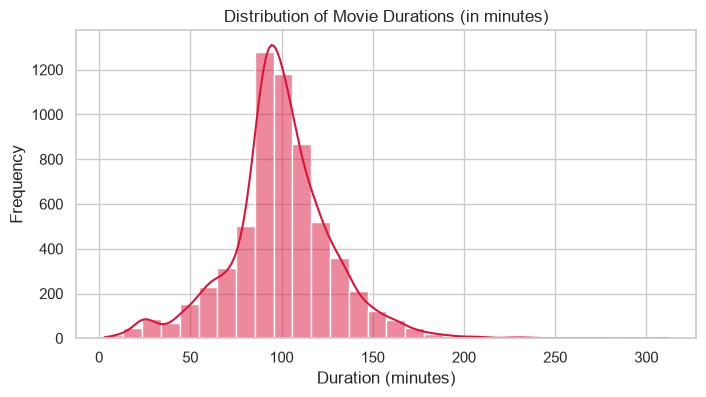

In [481]:
movies_df = df[df['type'] == 'Movie']

plt.figure(figsize=(8,4))
sns.histplot(movies_df['duration_value'],kde=True, bins=30,color='crimson')
plt.title('Distribution of Movie Durations (in minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

### 4. Content Additions Over Time ('year_added')

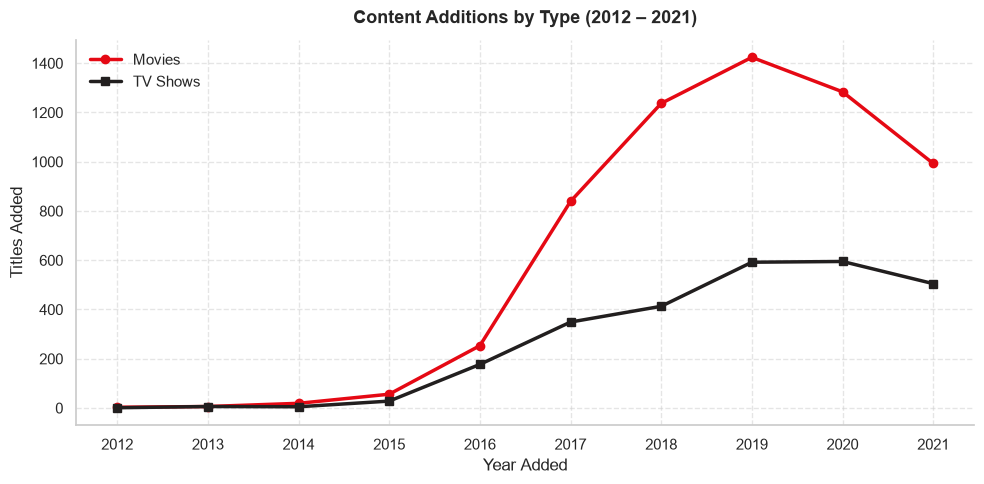

In [482]:
### Define color constants
NETFLIX_RED = '#E50914'
DARK_GRAY = '#221F1F'

# Get the latest year dynamically from the dataset
max_year = int(df['year_added'].max())

# Content Additions by Type (2012 – Present / Max Year)
timeline = df[(df['year_added'] >= 2012) & (df['year_added'] <= max_year)].groupby(['year_added', 'type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(timeline.index, timeline['Movie'], marker='o', linewidth=2.5, color=NETFLIX_RED, label='Movies')
ax.plot(timeline.index, timeline['TV Show'], marker='s', linewidth=2.5, color=DARK_GRAY, label='TV Shows')

ax.set_title(f'Content Additions by Type (2012 – {max_year})', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Year Added')
ax.set_ylabel('Titles Added')
ax.set_xticks(timeline.index)  # Ensures every year is shown on the x-axis
ax.legend(frameon=False)
ax.grid(True, linestyle='--', alpha=0.5)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### 5. Top 10 Producing Countries (`country_list`)

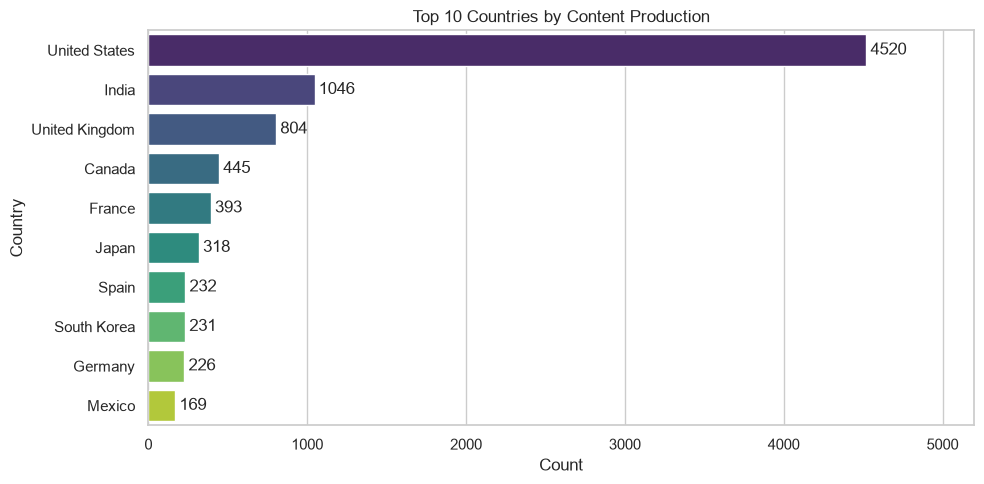

In [483]:
## 5.1. Explode country_list and reset index to ensure unique row labels
exploded_countries = df.explode('country_list').reset_index(drop=True)

## 5.2. Get the top 10 countries and counts
top_10_countries = exploded_countries['country_list'].value_counts().head(10).reset_index()
top_10_countries.columns = ['Country', 'Count']

## 5.3. Plot without redundant legend
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=top_10_countries,
    x='Count',
    y='Country',
    hue='Country',
    palette='viridis',
    legend=False
)

## 5.4. Add data labels on top/end of each bar
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Top 10 Countries by Content Production')
plt.xlabel('Count')
plt.ylabel('Country')

## Add extra headroom on x-axis for bar labels
plt.xlim(0, top_10_countries['Count'].max() * 1.15)
plt.tight_layout()
plt.show()


### 6. Content Counts Across Detailed Maturity Ratings

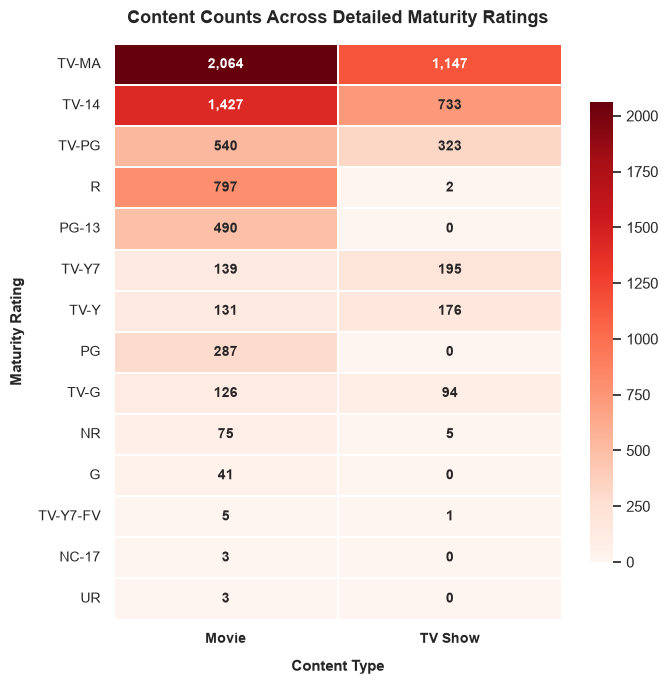

In [484]:
## 6.1. Filter out dirty rating entries (duration values like '66 min', '84 min', '74 min')
valid_ratings = ['TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13', 'TV-Y7', 'TV-Y', 'PG', 'TV-G', 'NR', 'G', 'TV-Y7-FV', 'NC-17', 'UR']
clean_df = df[df['rating'].isin(valid_ratings)]

## 6.2. Create cross-tabulation and sort by total volume
rating_ct = pd.crosstab(clean_df['rating'], clean_df['type'])
rating_ct = rating_ct.loc[rating_ct.sum(axis=1).sort_values(ascending=False).index]

## 6.3. Plot setup
fig, ax = plt.subplots(figsize=(7, 7))

sns.heatmap(
    rating_ct, 
    annot=True, 
    fmt=',d',                 # Format numbers with commas (e.g., 2,064)
    cmap='Reds',              # Red palette matching Netflix branding
    cbar=True,                # Add colorbar for visual scale
    cbar_kws={'shrink': 0.8},
    linewidths=1.2,           # Cell borders
    linecolor='white',
    annot_kws={'size': 10, 'weight': 'bold'}
)

## 6.4. Custom Styling
ax.set_title('Content Counts Across Detailed Maturity Ratings', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Content Type', fontsize=11, fontweight='semibold', labelpad=10)
ax.set_ylabel('Maturity Rating', fontsize=11, fontweight='semibold', labelpad=10)

# Rotate labels for cleaner layout
plt.xticks(fontsize=10, fontweight='bold')
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

### 7.Target Audience & Maturity Distribution by Content Type

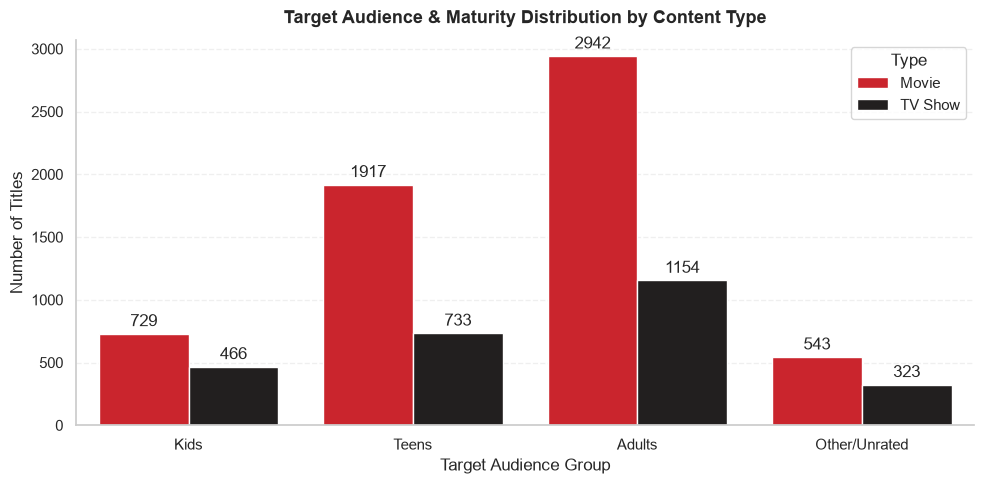

In [485]:
## 7.1. Map ratings to audience categories
rating_map = {
    'TV-Y': 'Kids', 'TV-Y7': 'Kids', 'G': 'Kids', 'TV-G': 'Kids', 'PG': 'Kids', 'TV-Y7-FV': 'Kids',
    'PG-13': 'Teens', 'TV-14': 'Teens',
    'R': 'Adults', 'TV-MA': 'Adults', 'NC-17': 'Adults', 'UR': 'Adults', 'NR': 'Adults'
}

df['target_audience'] = df['rating'].map(rating_map).fillna('Other/Unrated')

### Order for consistent layout
audience_order = ['Kids', 'Teens', 'Adults', 'Other/Unrated']

## 7.2. Create the plot
plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=df,
    x='target_audience',
    hue='type',
    order=audience_order,
    palette=['#E50914', '#221F1F']
)

# Add data labels on top of bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Target Audience & Maturity Distribution by Content Type', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Target Audience Group')
plt.ylabel('Number of Titles')
plt.legend(title='Type', frameon=True)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Hide top and right borders
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Add top padding for numerical labels
plt.ylim(0, df['target_audience'].value_counts().max() * 0.75)

plt.tight_layout()
plt.show()

---

## Probability Distributions

### 1. Fit & Test Continuous Distributions (Movie Runtime)

This script fits standard distributions (Normal, Lognormal, and Gamma) to duration_value for Movies and uses the Kolmogorov-Smirnov (K-S) test to determine which distribution best fits movie lengths.

--- Goodness-of-Fit (K-S Test p-values) ---
Normal Distribution p-value:    2.9843e-39
Lognormal Distribution p-value: 6.6497e-43
Gamma Distribution p-value:     1.2864e-44


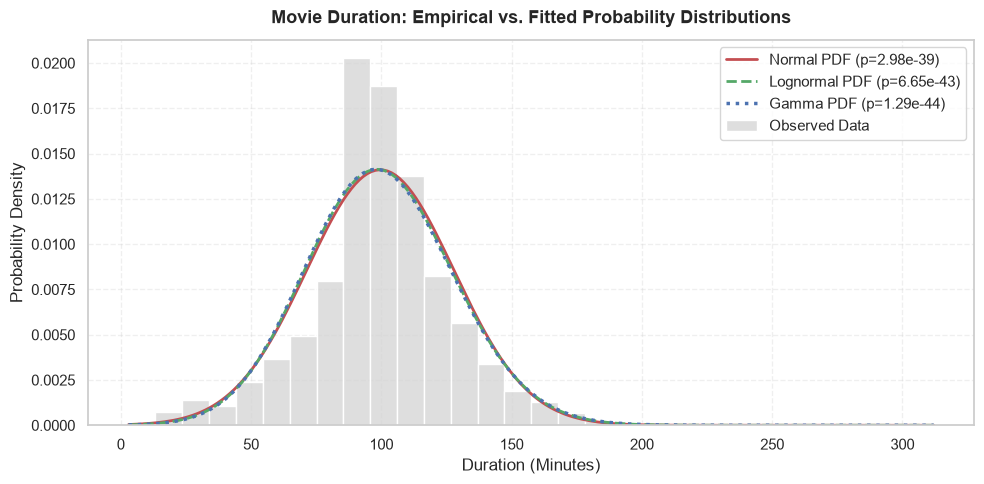

In [486]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Filter movie durations
movie_durations = df[df['type'] == 'Movie']['duration_value'].dropna()

# 2. Fit candidate distributions
norm_params = stats.norm.fit(movie_durations)
lognorm_params = stats.lognorm.fit(movie_durations)
gamma_params = stats.gamma.fit(movie_durations)

# 3. Perform Kolmogorov-Smirnov Goodness-of-Fit Tests
ks_norm = stats.kstest(movie_durations, stats.norm(*norm_params).cdf)
ks_lognorm = stats.kstest(movie_durations, stats.lognorm(*lognorm_params).cdf)
ks_gamma = stats.kstest(movie_durations, stats.gamma(*gamma_params).cdf)

print("--- Goodness-of-Fit (K-S Test p-values) ---")
print(f"Normal Distribution p-value:    {ks_norm.pvalue:.4e}")
print(f"Lognormal Distribution p-value: {ks_lognorm.pvalue:.4e}")
print(f"Gamma Distribution p-value:     {ks_gamma.pvalue:.4e}")

# 4. Visual Comparison of Fitted PDFs
x = np.linspace(movie_durations.min(), movie_durations.max(), 200)

plt.figure(figsize=(10, 5))
sns.histplot(movie_durations, stat="density", bins=30, color="lightgray", label="Observed Data")

plt.plot(x, stats.norm.pdf(x, *norm_params), 'r-', lw=2, label=f'Normal PDF (p={ks_norm.pvalue:.2e})')
plt.plot(x, stats.lognorm.pdf(x, *lognorm_params), 'g--', lw=2, label=f'Lognormal PDF (p={ks_lognorm.pvalue:.2e})')
plt.plot(x, stats.gamma.pdf(x, *gamma_params), 'b:', lw=2.5, label=f'Gamma PDF (p={ks_gamma.pvalue:.2e})')

plt.title('Movie Duration: Empirical vs. Fitted Probability Distributions', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Duration (Minutes)')
plt.ylabel('Probability Density')
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Empirical & Conditional Probability Matrix
Calculates joint and conditional probabilities 
    (e.g., $P(\text{Adults} \mid \text{Movie})$ vs $P(\text{Adults} \mid \text{TV Show})$) across target audience categories.

--- Joint Probability Matrix P(Audience, Type) ---
type              Movie  TV Show
target_audience                 
Adults           0.3341   0.1310
Kids             0.0828   0.0529
Other/Unrated    0.0617   0.0367
Teens            0.2177   0.0832


--- Conditional Probability P(Audience | Type) ---
type              Movie  TV Show
target_audience                 
Adults           0.4799   0.4312
Kids             0.1189   0.1741
Other/Unrated    0.0886   0.1207
Teens            0.3127   0.2739


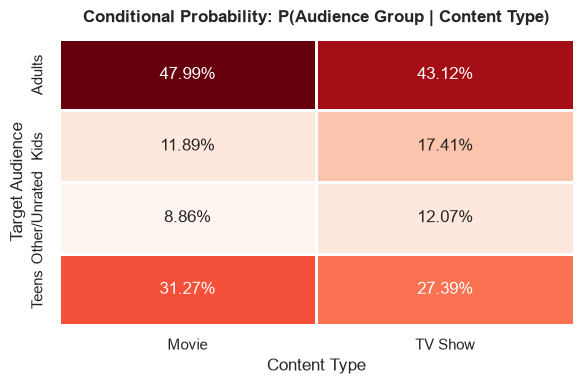

In [487]:
# 1. Joint Probability Distribution Matrix (Sums to 1.0)
joint_prob = pd.crosstab(df['target_audience'],df['type'],normalize='all')
print("--- Joint Probability Matrix P(Audience, Type) ---")
print(joint_prob.round(4))
print("\n" + "="*50 + "\n")

# 2. Conditional Probability P(Target Audience | Content Type)
cond_prob_given_type = pd.crosstab(df['target_audience'],df['type'], normalize='columns')
print("--- Conditional Probability P(Audience | Type) ---")
print(cond_prob_given_type.round(4))

# 3. Plot Conditional Probabilities Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cond_prob_given_type, annot=True, fmt=".2%", cmap="Reds", cbar=False, linewidths=1, linecolor="white")
plt.title('Conditional Probability: P(Audience Group | Content Type)', fontweight='bold', pad=12)
plt.xlabel('Content Type')
plt.ylabel('Target Audience')
plt.tight_layout()
plt.show()

### 3. Poisson Distribution Model (Monthly Catalog Additions)
Models the distribution of monthly title additions as a Poisson process to analyze content drop velocity.

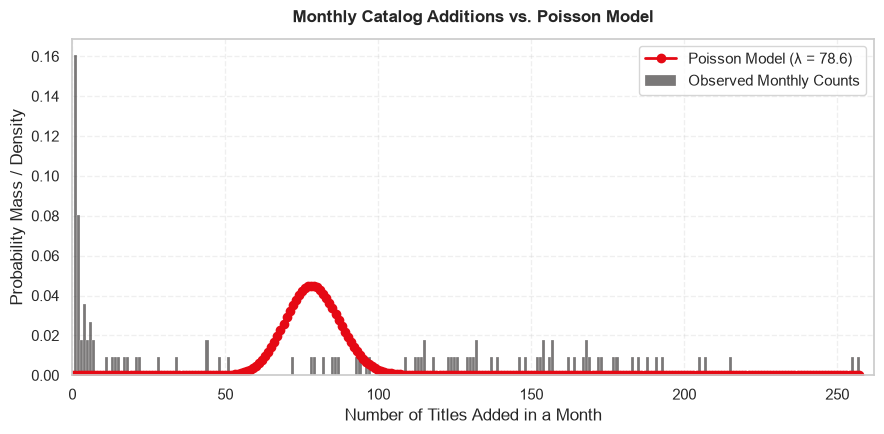

In [488]:
# 1. Count titles added per month
monthly_additions = df.groupby(['year_added', 'month_added']).size()

# 2. Calculate Poisson parameter (Lambda = mean additions per month)
lam = monthly_additions.mean()

# 3. Compare empirical distribution against theoretical Poisson distribution
k = np.arange(0, monthly_additions.max() + 1)
poisson_pmf = stats.poisson.pmf(k, mu=lam)

plt.figure(figsize=(9, 4.5))
sns.histplot(monthly_additions, stat="density", discrete=True, color="#221F1F", label="Observed Monthly Counts", alpha=0.6)
plt.plot(k, poisson_pmf, 'o-', color="#E50914", lw=2, label=f'Poisson Model (λ = {lam:.1f})')

plt.title('Monthly Catalog Additions vs. Poisson Model', fontweight='bold', pad=12)
plt.xlabel('Number of Titles Added in a Month')
plt.ylabel('Probability Mass / Density')
plt.xlim(0, monthly_additions.max() + 5)
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2. Hypothesis Testing

### Test 1: Chi-Square Test of Independence (Target Audience vs. Content Type)
- $H_0$: Target audience distribution is independent of content type (Movie vs. TV Show).
- $H_1$: Target audience distribution depends on content type.

In [489]:
from scipy.stats import chi2_contingency

# 1. Contingency Table
contingency_table = pd.crosstab(df['target_audience'], df['type'])

# 2. Chi-Square Test
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

alpha = 0.05
verdict = "REJECT Null Hypothesis (Significant Relationship)" if p_val < alpha else "FAIL TO REJECT Null Hypothesis (No Significant Relationship)"

print("=== Test 1: Target Audience vs. Content Type ===")
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"p-value:        {p_val:.4e}")
print(f"Verdict:        {verdict}\n")

=== Test 1: Target Audience vs. Content Type ===
Chi2 Statistic: 80.2215
p-value:        2.7512e-17
Verdict:        REJECT Null Hypothesis (Significant Relationship)



### Test 2: Mann-Whitney U Test (US vs. Non-US Movie Runtime)
- $H_0$: Mean runtime of US movies equals mean runtime of Non-US movies ($\mu_{\text{US}} = \mu_{\text{non-US}}$).
- $H_1$: Mean runtimes are significantly different ($\mu_{\text{US}} \neq \mu_{\text{non-US}}$).

In [490]:
from scipy.stats import mannwhitneyu

us_movies = df[(df['type'] == 'Movie') & (df['country'] == 'United States')]['duration_value'].dropna()
non_us_movies = df[(df['type'] == 'Movie') & (df['country'] != 'United States')]['duration_value'].dropna()

stat, p_val = mannwhitneyu(us_movies, non_us_movies)

verdict = "REJECT Null Hypothesis (Runtime Difference is Significant)" if p_val < alpha else "FAIL TO REJECT Null Hypothesis (No Significant Difference)"

print("=== Test 2: Movie Runtime (US vs. Non-US) ===")
print(f"U-Statistic: {stat:.4f}")
print(f"p-value:     {p_val:.4e}")
print(f"Verdict:     {verdict}\n")

=== Test 2: Movie Runtime (US vs. Non-US) ===
U-Statistic: 2953244.0000
p-value:     9.2834e-120
Verdict:     REJECT Null Hypothesis (Runtime Difference is Significant)



# Test 3: Kruskal-Wallis Test (Movie Duration Across Target Audiences)
- $H_0$: Movie runtimes are identical across Kids, Teens, and Adults content.
- $H_1$: At least one target audience group has a significantly different movie runtime.

In [491]:
from scipy.stats import kruskal

kids_dur = df[(df['type'] == 'Movie') & (df['target_audience'] == 'Kids')]['duration_value'].dropna()
teens_dur = df[(df['type'] == 'Movie') & (df['target_audience'] == 'Teens')]['duration_value'].dropna()
adults_dur = df[(df['type'] == 'Movie') & (df['target_audience'] == 'Adults')]['duration_value'].dropna()

stat, p_val = kruskal(kids_dur, teens_dur, adults_dur)

verdict = "REJECT Null Hypothesis (Significant Difference Across Groups)" if p_val < alpha else "FAIL TO REJECT Null Hypothesis (No Significant Difference)"

print("=== Test 3: Movie Runtime across Audience Groups ===")
print(f"H-Statistic: {stat:.4f}")
print(f"p-value:     {p_val:.4e}")
print(f"Verdict:     {verdict}\n")

=== Test 3: Movie Runtime across Audience Groups ===
H-Statistic: 628.1280
p-value:     4.0156e-137
Verdict:     REJECT Null Hypothesis (Significant Difference Across Groups)



### Test 4: One-Sample Binomial Test (Proportion of Movies in Catalog)
- $H_0$: Movies constitute $65\%$ or less of total catalog items ($p \le 0.65$).
- $H_1$: Movies constitute strictly more than $65\%$ of the catalog ($p > 0.65$).

In [492]:
from scipy.stats import binomtest

n_movies = (df['type'] == 'Movie').sum()
n_total = len(df)

result = binomtest(n_movies, n_total, p=0.65, alternative='greater')
p_val = result.pvalue

verdict = "REJECT Null Hypothesis (Movies make up significantly > 65% of catalog)" if p_val < alpha else "FAIL TO REJECT Null Hypothesis"

print("=== Test 4: Catalog Proportion of Movies ===")
print(f"Movie Count: {n_movies} / {n_total} ({n_movies/n_total:.2%})")
print(f"p-value:     {p_val:.4e}")
print(f"Verdict:     {verdict}\n")

=== Test 4: Catalog Proportion of Movies ===
Movie Count: 6131 / 8807 (69.62%)
p-value:     2.3695e-20
Verdict:     REJECT Null Hypothesis (Movies make up significantly > 65% of catalog)



---
## Correlation Heatmap

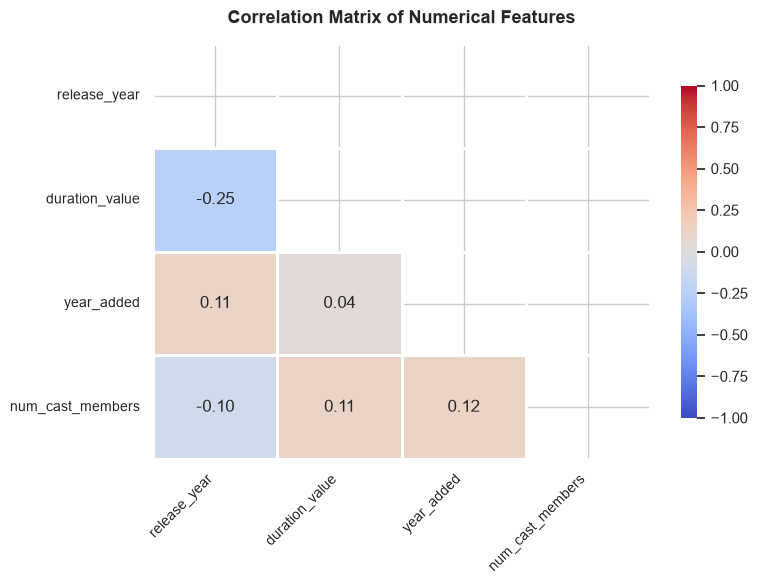

In [493]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select numeric features for correlation analysis
numeric_cols = ['release_year', 'duration_value', 'year_added', 'num_cast_members']
corr_matrix = df[numeric_cols].corr()

# 2. Plot setup
plt.figure(figsize=(8, 6))

# Generate a mask for the upper triangle to avoid redundant information
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Create Heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=1,
    linecolor="white",
    cbar_kws={"shrink": 0.8}
)

# 4. Custom Styling
plt.title('Correlation Matrix of Numerical Features', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

---